# Feature Engineering — 20 Advanced Behavioral Features

This notebook computes **20 customer-level features** across **5 behavioral families** from the raw dataset and the RFM dataset to help the model work more efficently. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from IPython.display import display

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [3]:

DATA_PATH = '../data/raw/ecommerce-data.csv'
df = pd.read_csv(DATA_PATH, encoding='unicode_escape')
print(f"Raw data shape: {df.shape}")
df.head(3)

Raw data shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom


In [4]:
# Keep cancellation invoices — they are needed for ReturnRate / ReturnValueRate

print(f"Initial shape: {df.shape}")

# 1. Drop full-row duplicates
df.drop_duplicates(keep='first', inplace=True)
print(f"After dedup: {df.shape}")

# 2. Parse InvoiceDate
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 3. Fill UnitPrice = 0 with mode per StockCode, then drop remaining zeros
df.loc[df['UnitPrice'] <= 0, 'UnitPrice'] = np.nan
mode_prices = df.groupby('StockCode')['UnitPrice'].transform(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
)
df['UnitPrice'] = df['UnitPrice'].fillna(mode_prices)
df.dropna(subset=['UnitPrice'], inplace=True)
print(f"After UnitPrice fix: {df.shape}")

# 4. Fill Description from StockCode mapping, drop remaining nulls
desc_mapping = (
    df.dropna(subset=['Description'])
    .drop_duplicates('StockCode')
    .set_index('StockCode')['Description']
)
df['Description'] = df['Description'].fillna(df['StockCode'].map(desc_mapping))
df.dropna(subset=['Description'], inplace=True)

# 5. Drop null CustomerID — cannot segment anonymous customers
df.dropna(subset=['CustomerID'], inplace=True)
df['CustomerID'] = df['CustomerID'].astype(int)
print(f"After dropping null CustomerID: {df.shape}")

# 6. Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(f"\nFinal cleaned shape: {df.shape}")
print(f"Unique customers: {df['CustomerID'].nunique()}")
print(f"Date range: {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")

Initial shape: (541909, 8)
After dedup: (536641, 8)
After UnitPrice fix: (536507, 8)
After dropping null CustomerID: (401604, 8)

Final cleaned shape: (401604, 9)
Unique customers: 4372
Date range: 2010-12-01 08:26:00 → 2011-12-09 12:50:00


In [5]:
# Cancellation invoices start with 'C'
is_cancel = df['InvoiceNo'].astype(str).str.startswith('C')

df_cancels = df[is_cancel].copy()
df_sales = df[~is_cancel].copy()

# For sales, enforce positive Quantity (should already be, but be safe)
df_sales = df_sales[df_sales['Quantity'] > 0]

print(f"Sales transactions: {df_sales.shape[0]:,}")
print(f"Cancellation transactions: {df_cancels.shape[0]:,}")
print(f"Customers in sales: {df_sales['CustomerID'].nunique():,}")
print(f"Customers with cancellations: {df_cancels['CustomerID'].nunique():,}")

Sales transactions: 392,732
Cancellation transactions: 8,872
Customers in sales: 4,339
Customers with cancellations: 1,589


In [6]:
# Helper function

# Helper: coefficient of variation (returns 0 if std or mean is 0)
def cv(series):
    """Coefficient of variation, safe for constant series."""
    m = series.mean()
    if m == 0 or len(series) < 2:
        return 0.0
    return series.std() / m

# Helper: Gini coefficient
def gini(values):
    """Gini coefficient of a list of values."""
    arr = np.sort(np.array(values, dtype=float))
    n = len(arr)
    if n == 0 or arr.sum() == 0:
        return 0.0
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * arr) - (n + 1) * np.sum(arr)) / (n * np.sum(arr))

In [7]:
# Reference date = 1 day after last transaction
reference_date = df_sales['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date}")

# Build per-order summaries first (for order-level features)
order_summary = df_sales.groupby(['CustomerID', 'InvoiceNo']).agg(
    order_date=('InvoiceDate', 'min'),
    order_total=('TotalPrice', 'sum'),
    line_count=('StockCode', 'count'),
    total_qty=('Quantity', 'sum'),
    unique_skus=('StockCode', 'nunique'),
).reset_index()

print(f"Order summary: {order_summary.shape[0]:,} orders")

customer_summary = order_summary.groupby('CustomerID')
display(customer_summary.head())

Reference date: 2011-12-10 12:50:00
Order summary: 18,536 orders


,CustomerID,InvoiceNo,order_date,order_total,line_count,total_qty,unique_skus
0,12346,541431,2011-01-18 10:01:00,77183.60,1,74215,1
1,12347,537626,2010-12-07 14:57:00,711.79,31,319,31
2,12347,542237,2011-01-26 14:30:00,475.39,29,315,29
3,12347,549222,2011-04-07 10:43:00,636.25,24,483,24
4,12347,556201,2011-06-09 13:01:00,382.52,18,196,18
...,...,...,...,...,...,...,...
18520,18283,550957,2011-04-21 16:37:00,115.60,55,86,55
18521,18283,554157,2011-05-23 11:33:00,85.22,37,55,32
18533,18287,554065,2011-05-22 10:39:00,765.28,29,488,27
18534,18287,570715,2011-10-12 10:23:00,1001.32,38,990,38


### 1. Feature Family: Purchase Rhythm

**Objective:** This feature group goes beyond merely counting transactions. It evaluates the **rhythm**, **stability**, and **churn risk** of each customer. These features effectively address the inherent blind spots of the traditional Recency and Frequency metrics in the standard RFM model.

**Feature Details:**

* **`Recency`:** The number of days from the customer's last purchase to the dataset's snapshot date.
  * *Business Value:* Differentiates currently active customers from those who have likely churned.
* **`ActiveSpanDays` (Customer Lifespan):** The number of days between the customer's first and last invoice.
  * *Business Value:* Assesses the reliability of the customer's purchasing history (e.g., distinguishing a long-term loyal customer from a short-term/one-off buyer).
* **`MonthlyOrderRate`:** Total number of orders / (ActiveSpanDays / 30).
  * *Business Value:* Reflects the true purchasing frequency. It fixes a major RFM flaw by creating a fair comparison between newly acquired customers (low total orders but high purchasing rhythm) and veteran customers (high total orders but low rhythm).
* **`InterPurchaseCV` (Purchase Gap Variation):** The Coefficient of Variation (Standard Deviation / Mean) of the days between consecutive purchases.
  * *Business Value:* Measures purchasing "consistency". A $CV \approx 0$ indicates a highly stable, habitual buyer (perfect targets for Subscription models). A high $CV$ reveals impulsive, erratic, or seasonal buying behaviors (ideal targets for Flash Sales).
* **`RecencyAnomaly` (Churn Warning Index):** The ratio of current Recency to the customer's Mean Purchase Gap (`Recency / Mean_Gap`).
  * *Business Value:* Acts as an early warning system for churn. If this ratio is highly elevated (e.g., $> 2.0$), the customer is severely lagging behind their own historical buying rhythm, indicating a high probability that they are churning to a competitor.


In [8]:
# FAMILY 1: Purchase Rhythm
def purchase_rhythm_features(group):
    """Compute Recency, InterPurchaseCV, ActiveSpanDays, MonthlyOrderRate,RecencyAnomaly."""
    dates = group['order_date'].sort_values()
    n_orders = len(dates)
    last_date = dates.iloc[-1]
    first_date = dates.iloc[0]

    recency = (reference_date - last_date).days
    active_span = (last_date - first_date).days

    if n_orders < 2:
        inter_cv = 0.0
        monthly_rate = float(n_orders)  # treat as 1 month
        recency_anomaly=1.0
    else:
        gaps = dates.diff().dt.days.dropna()
        inter_cv = cv(gaps)
        months = max(active_span / 30.44, 1.0)
        monthly_rate = n_orders / months
        mean_gap = gaps.mean()
        recency_anomaly = recency / max(mean_gap, 1.0)

    return pd.Series({
        'Recency': recency,
        'InterPurchaseCV': inter_cv,
        'ActiveSpanDays': active_span,
        'MonthlyOrderRate': monthly_rate,
        'RecencyAnomaly': recency_anomaly
    })

print("Computing Purchase Rhythm features...")
f_rhythm = order_summary.groupby('CustomerID').apply(
    purchase_rhythm_features, include_groups=False
)

Computing Purchase Rhythm features...


### 2. Feature Family: Spend Shape

**Objective:** This feature group addresses the primary blind spot of the Monetary (M) metric in traditional RFM. Two customers might both spend $1,000, but one makes ten $100 purchases while the other makes a single $1,000 purchase. These features help the model understand a customer's budget allocation, price sensitivity, and spending momentum over time.

**Feature Details:**

* **`AOV` (Average Order Value):** Total revenue divided by the total number of orders.
  * *Business Value:* Separates premium shoppers (high-value baskets) from budget-conscious/frequent shoppers (small, incremental baskets). This is crucial for determining free shipping thresholds or targeted discount tiers.
* **`AIV` (Average Item Value):** Total revenue divided by the total quantity of items purchased.
  * *Business Value:* Differentiates purchasing tiers that AOV might miss. For example, two customers might both have an AOV of $100. However, Customer A bought one premium item for $100 (AIV = $100), while Customer B bought 100 cheap items for $1 each (AIV = $1). This feature helps the model explicitly cluster "Premium Shoppers" vs. "Bargain/Bulk Shoppers", allowing for highly accurate product recommendations.
* **`SpendGini` (Spend Gini Coefficient):** Measures the inequality among a single customer's invoice values (0 = all invoices have the exact same value; approaching 1.0 = spending is heavily skewed toward one massive invoice).
  * *Business Value:* Flags "artificial VIPs". A customer with a high Monetary value but a high SpendGini (e.g., 0.9) likely just made one huge bulk or event-driven purchase. They shouldn't be treated as consistent, high-value loyalists.
* **`PriceCV` (Price Coefficient of Variation):** The Coefficient of Variation of the unit prices of items the customer has purchased.
  * *Business Value:* Measures "price sensitivity" and basket diversity. A low PriceCV means the customer strictly sticks to a specific price tier. A high PriceCV indicates a versatile shopper willing to buy across all price points (from $1 knick-knacks to $100 premium items).
* **`MaxSpendShare`:** The revenue from the customer's largest single invoice divided by their total spend (Monetary).
  * *Business Value:* Highly correlated with SpendGini but more straightforward. K-Means uses this to identify customers whose lifetime value is heavily anchored by a single transaction, preventing marketing from misallocating VIP retention budgets on "one-hit wonders."
* **`SpendAcceleration`:** The slope (trendline) of the customer's order values over time.
  * *Business Value:* Captures "spending momentum". A positive slope (+) means the customer is spending progressively more with each subsequent order (prime targets for up-selling). A negative slope (-) indicates shrinking basket sizes, serving as a strong early warning sign of waning interest or potential churn.

In [9]:
# FAMILY 2: Spend Shape
def spend_shape_features(group):
    """Compute AOV, SpendGini, PriceCV, MaxSpendShare, SpendAcceleration."""
    totals = group['order_total'].values
    n_orders = len(totals)
    total_spend = totals.sum()
    n_items= group['total_qty'].values.sum()

    aov = total_spend / n_orders if n_orders > 0 else 0.0
    aiv = total_spend / n_items if n_items >0 else 0.0
    spend_gini = gini(totals)
    max_spend_share = totals.max() / total_spend if total_spend > 0 else 1.0

    # SpendAcceleration: spend in 2nd half / spend in 1st half of active span
    if n_orders < 2:
        spend_accel = 1.0
    else:
        dates = group['order_date'].sort_values().values
        midpoint = dates[0] + (dates[-1] - dates[0]) / 2
        first_half = totals[group['order_date'].values <= midpoint].sum()
        second_half = totals[group['order_date'].values > midpoint].sum()
        spend_accel = second_half / max(first_half, 1e-6)

    return pd.Series({
        'AOV': aov,
        'AIV': aiv,
        'SpendGini': spend_gini,
        'MaxSpendShare': max_spend_share,
        'SpendAcceleration': spend_accel,
    })

# PriceCV is computed from line-item level, not order level
print("Computing Spend Shape features...")
f_spend = order_summary.groupby('CustomerID').apply(
    spend_shape_features, include_groups=False
)

# PriceCV: CV of UnitPrice across all line items per customer
price_cv = df_sales.groupby('CustomerID')['UnitPrice'].apply(cv).rename('PriceCV')
f_spend = f_spend.join(price_cv)

Computing Spend Shape features...


### 3. Feature Family: Basket Behavior

**Objective:** This feature group looks past the monetary value and timestamps to examine the structural composition of the shopping cart. It reveals customer habits regarding product exploration, brand loyalty at the item level, and predictability of basket sizes.

**Feature Details:**

* **`RepeatSKUFraction`:** The ratio of previously purchased items (SKUs) to the total items in a customer's history.
  * *Business Value:* Identifies "habitual buyers" who repeatedly purchase the same consumables. High values indicate strong brand/item loyalty, making them perfect targets for automated replenishment reminders.
* **`NewSKURate`:** The propensity of a customer to add never-before-bought items to their cart.
  * *Business Value:* Measures receptiveness to product discovery. Customers with a high rate are highly explorative and are the ideal segment for cross-selling algorithms and new product launch campaigns.
* **`BasketSizeCV` (Basket Size Variation):** The Coefficient of Variation (Std / Mean) of the number of unique items across the customer's orders.
  * *Business Value:* Measures volumetric stability. A low CV means highly predictable, stable basket sizes (grocery-shopping style). A high CV flags erratic shopping behavior, often driven by external triggers like seasonal mega-sales.
* **`MedianBasketQty`:** The median number of items purchased per invoice.
  * *Business Value:* Represents the customer's "typical" basket capacity. We use the Median instead of the Mean to strictly protect the model from being heavily skewed by a single anomalous bulk-buy order in a retail customer's history.
* **`SingleItemOrderRate`:** The percentage of a customer's total orders that contain exactly one unique item (SKU).
  * *Business Value:* Identifies "mission-driven" shoppers who buy exactly what they need and leave, versus "browsers" who build large, diverse baskets. Crucial for tailoring UI experiences and deciding between cart-level discounts vs. item-level discounts.
* **`BasketDiversity`:** The ratio of unique items (SKUs) to the total quantity of items within a basket.
  * *Business Value:* An excellent proxy for identifying bulk/wholesale behavior. A low diversity score (e.g., buying 100 units of a single SKU) signals B2B or event-driven purchasing, whereas a high score (buying 10 different SKUs, 1 unit each) strongly indicates a typical B2C retail shopper.

In [10]:
# FAMILY 3: Basket Behavior
def basket_behavior_features(group):
    """Compute RepeatSKUFraction, BasketSizeCV, MedianBasketQty, NewSKURate."""
    n_orders = len(group)

    # BasketSizeCV: CV of line-item count per order
    basket_cv = cv(group['line_count']) if n_orders > 1 else 0.0

    # MedianBasketQty: median total quantity per order
    median_qty = group['total_qty'].median()

    #SingItemOrderRate: single SKU per order 
    single_item_rate = (group['unique_skus'] == 1).mean()    

    #OrderDiversity: rate unique SKU of total quantity
    order_diversity = (group['unique_skus'] / group['total_qty']).mean()

    return pd.Series({
        'BasketSizeCV': basket_cv,
        'MedianBasketQty': median_qty,
        'SingleItemOrderRate': single_item_rate,
        'OrderDiversiy': order_diversity
    })

print("Computing Basket Behavior features...")
f_basket = order_summary.groupby('CustomerID').apply(
    basket_behavior_features, include_groups=False
)

# RepeatSKUFraction: fraction of distinct SKUs purchased more than once (line-item level)
sku_counts = df_sales.groupby('CustomerID')['StockCode'].value_counts()
repeat_sku = sku_counts.groupby('CustomerID').apply(
    lambda x: (x > 1).mean()
).rename('RepeatSKUFraction')
f_basket = f_basket.join(repeat_sku)

# NewSKURate: fraction of orders containing at least one never-before-seen SKU
def new_sku_rate(cust_df):
    """For a customer's sales (sorted by date), what fraction of orders have a new SKU?"""
    cust_df = cust_df.sort_values('InvoiceDate')
    seen = set()
    orders = cust_df.groupby('InvoiceNo')
    new_count = 0
    total_orders = 0
    for _, order in orders:
        skus = set(order['StockCode'])
        if skus - seen:  # at least one new SKU
            new_count += 1
        seen.update(skus)
        total_orders += 1
    return new_count / total_orders if total_orders > 0 else 1.0

new_sku = df_sales.groupby('CustomerID').apply(
    new_sku_rate, include_groups=False
).rename('NewSKURate')
f_basket = f_basket.join(new_sku)


Computing Basket Behavior features...


### 4. Feature Family: Volume & B2B (Wholesale Behavior)

**Objective:** This group explicitly distinguishes between high-value retail customers (B2C VIPs) and wholesale/resellers (B2B). It leverages macroeconomic indicators and physical quantity distributions to identify bulk buyers, concentration of purchases, and ordering seasonality.

**Feature Details:**

* **`BulkLineRate`:** The percentage of a customer's line items where the quantity purchased is 24 units or more (2+ dozens).
  * *Business Value:* A direct indicator of wholesale behavior. Retail customers rarely buy individual items in quantities of two dozen or more, making this a strict threshold for identifying resellers.
* **`QuantityCV` (Quantity Coefficient of Variation):** The variation (Standard Deviation / Mean) of quantities purchased across all line items for a customer.
  * *Business Value:* Captures the mix of shopping behaviors. A high CV indicates a "hybrid" cart (e.g., buying 1 personal item alongside 200 items for a business), whereas a low CV indicates uniform volume across all items.
* **`SKU_HHI` (Herfindahl-Hirschman Index):** An economic index adapted to measure the concentration of a customer's purchases across different SKUs.
  * *Business Value:* An HHI approaching 1.0 means the customer is heavily concentrated on a few specific items (typical of a B2B distributor or niche specialist). An HHI approaching 0 indicates a highly diversified retail shopper exploring the entire catalog.
* **`BurstIndex`:** The ratio of orders in the peak purchasing month compared to the customer's average monthly orders.
  * *Business Value:* Identifies highly seasonal or event-driven buyers. A high BurstIndex isolates customers whose lifetime value is driven by sporadic, massive spikes (e.g., end-of-year corporate gifting) rather than steady, predictable habits.

In [11]:
# FAMILY 4: Volume & B2B
print("Computing Volume & B2B features...")

# BulkLineRate: fraction of line items with Quantity >= 24
bulk_rate = df_sales.groupby('CustomerID')['Quantity'].apply(
    lambda x: (x >= 24).mean()
).rename('BulkLineRate')

# QuantityCV: CV of Quantity across all line items
qty_cv = df_sales.groupby('CustomerID')['Quantity'].apply(cv).rename('QuantityCV')

# SKU_HHI: Herfindahl-Hirschman Index of SKU purchase shares
def hhi(sku_series):
    """HHI from a series of StockCodes."""
    shares = sku_series.value_counts(normalize=True)
    return (shares ** 2).sum()

sku_hhi = df_sales.groupby('CustomerID')['StockCode'].apply(hhi).rename('SKU_HHI')

# BurstIndex: max monthly order count / mean monthly order count
def burst_index(group):
    """Ratio of peak month's orders to average month's orders."""
    monthly = group['order_date'].dt.to_period('M').value_counts()
    if len(monthly) < 2:
        return 1.0
    return monthly.max() / monthly.mean()

burst = order_summary.groupby('CustomerID').apply(
    burst_index, include_groups=False
).rename('BurstIndex')

f_volume = pd.DataFrame({
    'BulkLineRate': bulk_rate,
    'QuantityCV': qty_cv,
    'SKU_HHI': sku_hhi,
    'BurstIndex': burst,
})

Computing Volume & B2B features...


### 5. Feature Family: Customer Lifecycle & Returns

**Objective:** This group captures the post-purchase behavior and macro-seasonality of the customer. It identifies high-maintenance customers who frequently cancel orders and isolates highly seasonal shoppers whose lifetime value is concentrated in a specific quarter.

**Feature Details:**

* **`ReturnRate`:** The number of cancellation invoices divided by the total number of invoices (sales + cancellations).
  * *Business Value:* Flags "toxic" or high-maintenance customers. High return rates drastically increase reverse logistics costs and should not be clustered with genuine high-value VIPs.
* **`ReturnValueRate`:** The absolute monetary value of all cancellations divided by the total gross sales value.
  * *Business Value:* Measures the financial impact of a customer's returns. A customer might have a low Return Rate (cancels rarely) but a high Return Value Rate (cancels extremely expensive orders).
* **`QuarterConcentration`:** The maximum percentage of a customer's orders that fall within a single calendar quarter.
  * *Business Value:* Differentiates between steady, year-round buyers (values near 0.25) and highly seasonal shoppers (values approaching 1.0). Useful for timing marketing campaigns and inventory planning.

In [12]:
# FAMILY 5: Customer Lifecycle
print("Computing Customer Lifecycle features...")

# ReturnRate: cancellation invoices / total invoices (sales + cancels)
sales_invoice_count = df_sales.groupby('CustomerID')['InvoiceNo'].nunique()
cancel_invoice_count = df_cancels.groupby('CustomerID')['InvoiceNo'].nunique()

# Align: fill NaN with 0 for customers with no cancellations
all_customers = sales_invoice_count.index
cancel_aligned = cancel_invoice_count.reindex(all_customers, fill_value=0)
total_invoices = sales_invoice_count + cancel_aligned
return_rate = (cancel_aligned / total_invoices).rename('ReturnRate')

# ReturnValueRate: |cancellation value| / total sales value
sales_value = df_sales.groupby('CustomerID')['TotalPrice'].sum()
cancel_value = df_cancels.groupby('CustomerID')['TotalPrice'].sum().abs()
cancel_value_aligned = cancel_value.reindex(all_customers, fill_value=0)
return_value_rate = (cancel_value_aligned / sales_value.clip(lower=1e-6)).rename('ReturnValueRate')

# QuarterConcentration: max quarterly order share
def quarter_concentration(group):
    """Max share of orders in any calendar quarter."""
    quarters = group['order_date'].dt.quarter.value_counts(normalize=True)
    return quarters.max()

q_conc = order_summary.groupby('CustomerID').apply(
    quarter_concentration, include_groups=False
).rename('QuarterConcentration')

f_lifecycle = pd.DataFrame({
    'ReturnRate': return_rate,
    'ReturnValueRate': return_value_rate,
    'QuarterConcentration': q_conc,
})

Computing Customer Lifecycle features...


In [ ]:
# Combine all 20 features
print("\nCombining all features...")
features = (
    f_rhythm
    .join(f_spend)
    .join(f_basket)
    .join(f_volume)
    .join(f_lifecycle)
)
features.index.name = 'CustomerID'

# Fill any remaining NaN (e.g., customers with no cancellations)
features = features.fillna(0)

print(f"Feature matrix shape: {features.shape}")
print(f"\nFeature columns ({len(features.columns)}):")
for i, col in enumerate(features.columns, 1):
    print(f"  {i:2d}. {col}")


Combining all features...
Feature matrix shape: (4339, 24)

Feature columns (24):
   1. Recency
   2. InterPurchaseCV
   3. ActiveSpanDays
   4. MonthlyOrderRate
   5. RecencyAnomaly
   6. AOV
   7. AIV
   8. SpendGini
   9. MaxSpendShare
  10. SpendAcceleration
  11. PriceCV
  12. BasketSizeCV
  13. MedianBasketQty
  14. SingleItemOrderRate
  15. OrderDiversiy
  16. RepeatSKUFraction
  17. NewSKURate
  18. BulkLineRate
  19. QuantityCV
  20. SKU_HHI
  21. BurstIndex
  22. ReturnRate
  23. ReturnValueRate
  24. QuarterConcentration


DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Recency,4339.0,92.5183,100.0097,1.0000,18.0000,51.0000,142.0000,374.0000
InterPurchaseCV,4339.0,0.3675,0.4800,0.0000,0.0000,0.0000,0.7362,3.1510
ActiveSpanDays,4339.0,130.4185,132.0392,0.0000,0.0000,92.0000,251.5000,373.0000
MonthlyOrderRate,4339.0,1.0473,0.9195,0.1668,0.6212,1.0000,1.0000,34.0000
RecencyAnomaly,4339.0,3.6096,22.6618,0.0042,0.3551,1.0000,1.0000,373.0000
AOV,4339.0,420.0205,1803.0397,3.4500,177.8318,292.0000,428.4042,84236.2500
AIV,4339.0,3.0134,33.2145,0.0856,1.4079,1.8067,2.3526,2033.1000
SpendGini,4339.0,0.1394,0.1483,0.0000,0.0000,0.1010,0.2432,0.7590
MaxSpendShare,4339.0,0.6232,0.3177,0.0240,0.3426,0.5738,1.0000,1.0000
SpendAcceleration,4339.0,14.9221,881.9194,0.0000,0.8449,1.0000,1.2956,58092.9655



NaN values: 0
Inf values: 0
✅ No NaN or Inf values


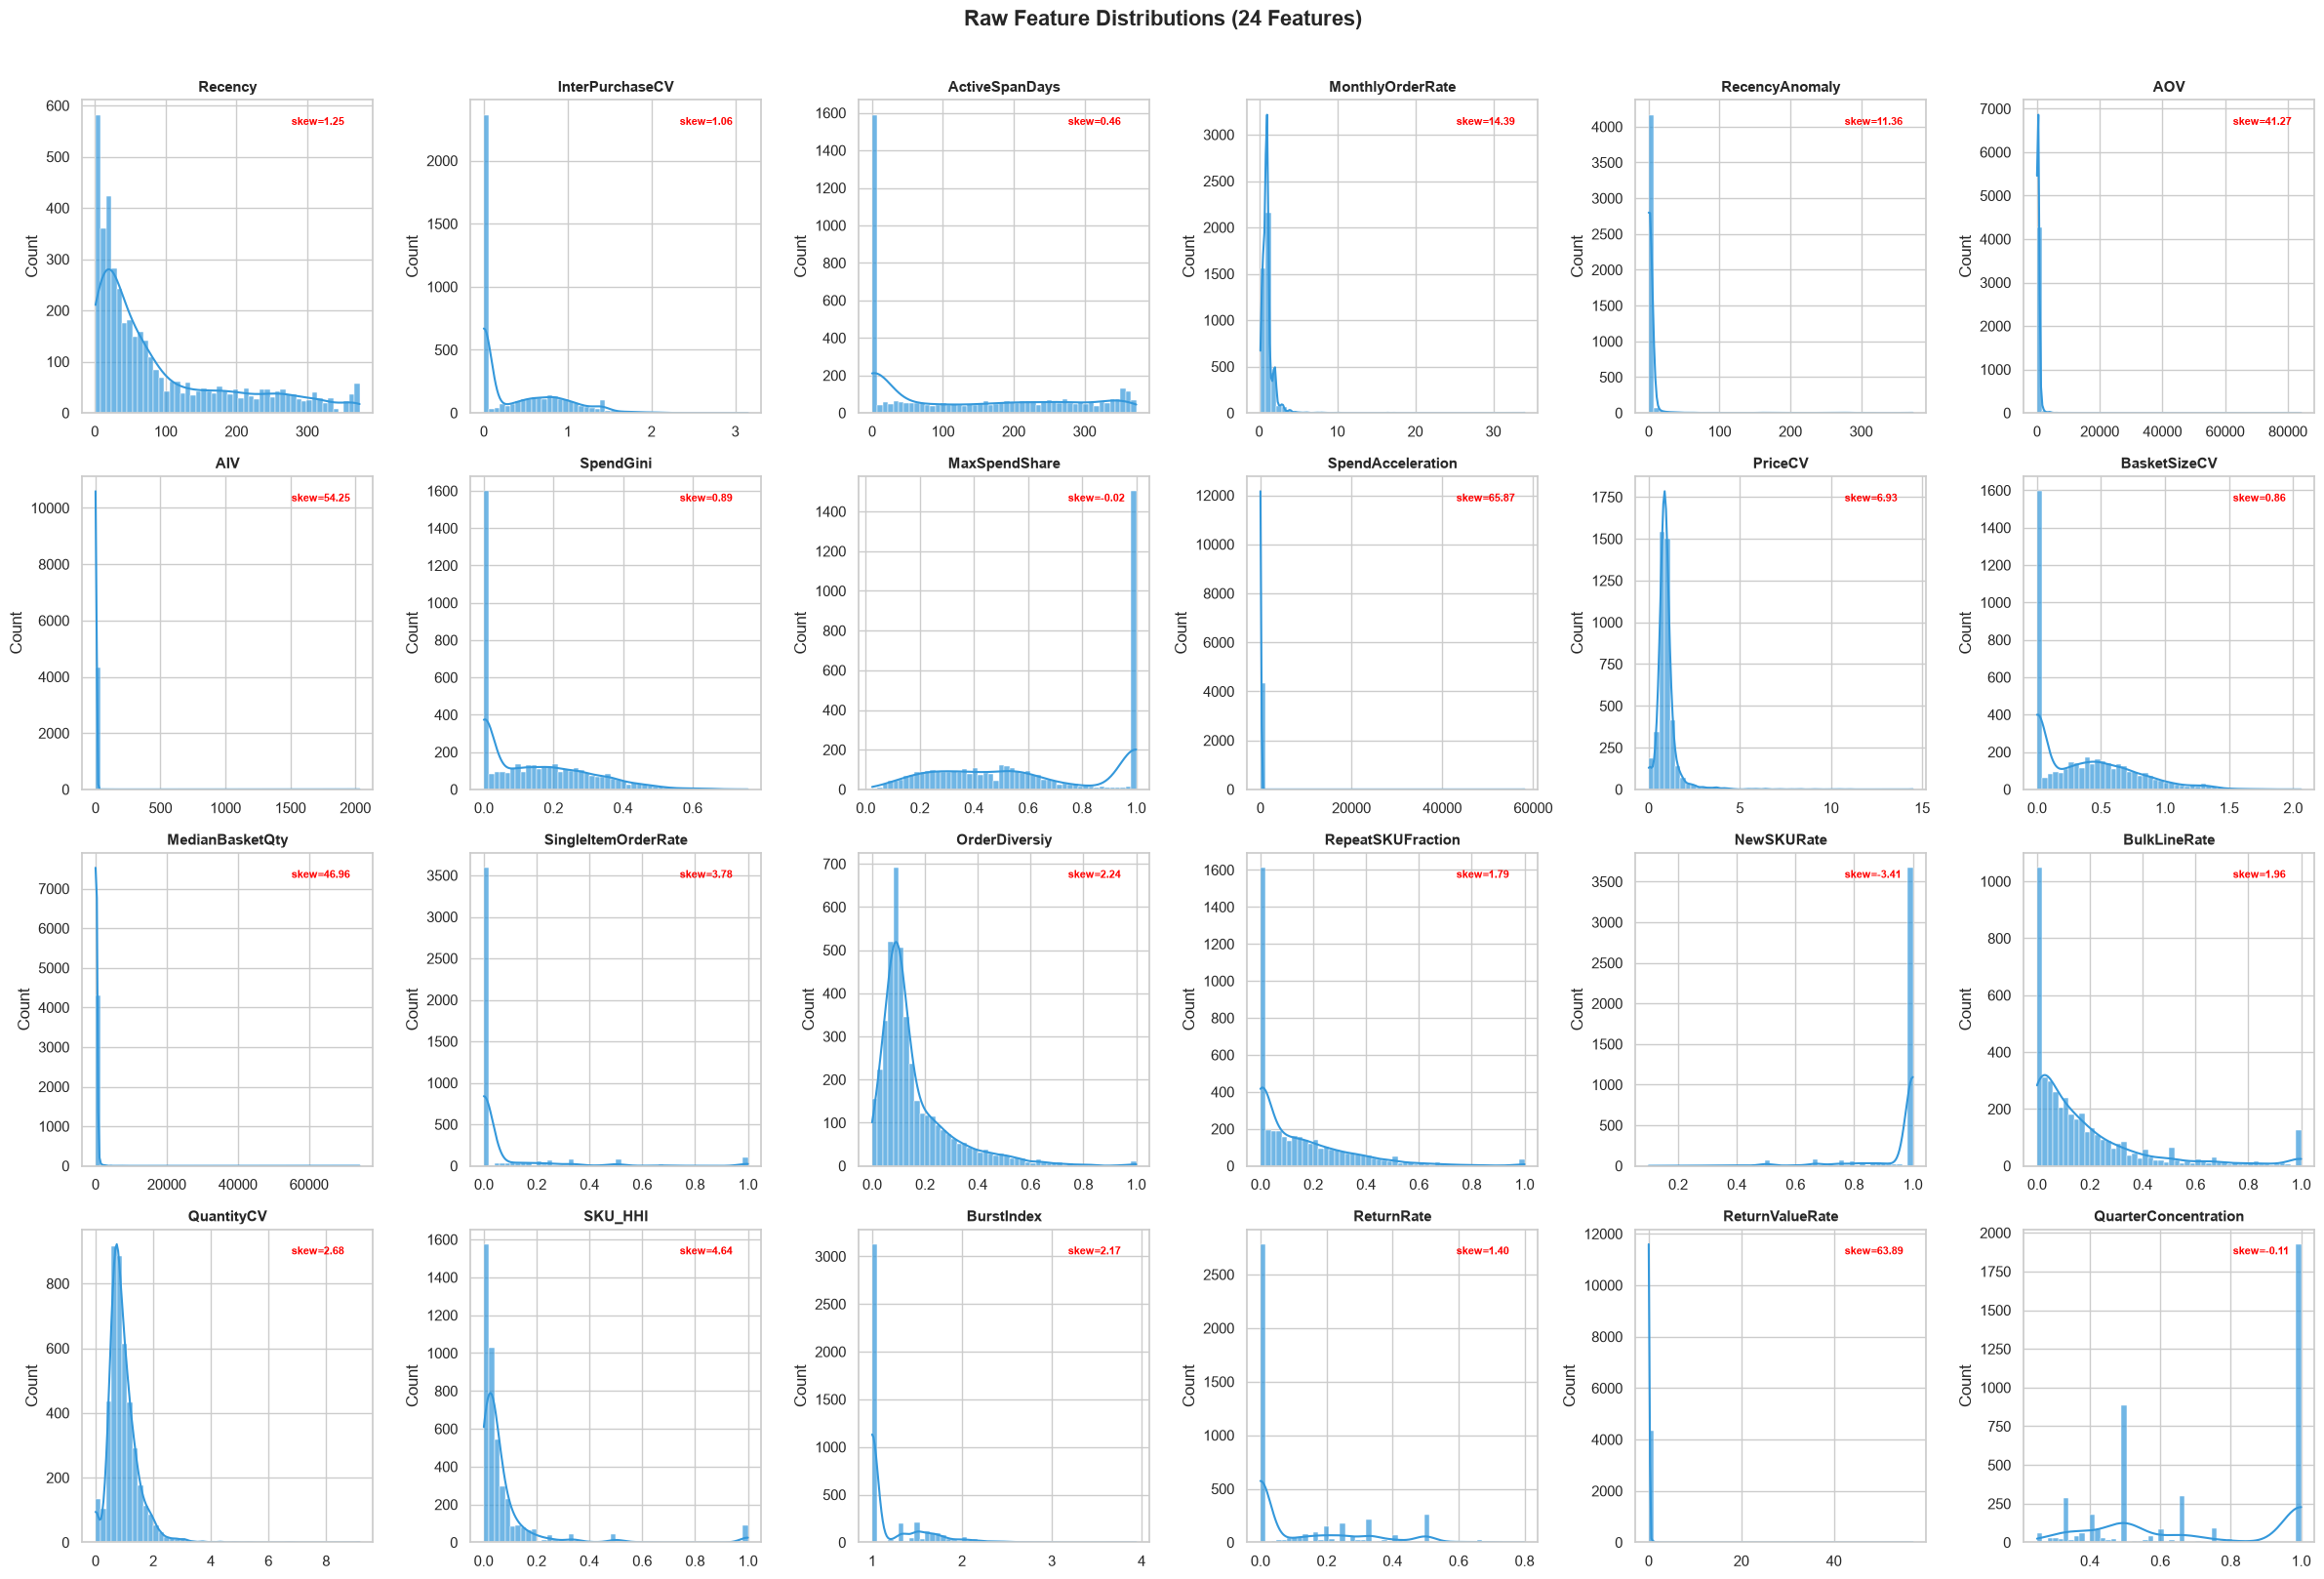

In [ ]:
# Descriptive stats
print("=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)
display(features.describe().T.round(4))

# Check for NaN / Inf
nan_count = features.isna().sum().sum()
inf_count = np.isinf(features.values).sum()
print(f"\nNaN values: {nan_count}")
print(f"Inf values: {inf_count}")
assert nan_count == 0, "NaN values found!"
assert inf_count == 0, "Inf values found!"
print("✅ No NaN or Inf values")

# Histogram grid (4×5) of raw feature distributions
fig, axes = plt.subplots(4, 6, figsize=(24, 16))
axes = axes.flatten()

for i, col in enumerate(features.columns):
    ax = axes[i]
    sns.histplot(features[col], kde=True, ax=ax, bins=50,
                 color='#3498db', edgecolor='white', alpha=0.7)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    # Add skewness annotation
    skew_val = features[col].skew()
    ax.annotate(f'skew={skew_val:.2f}', xy=(0.72, 0.92), xycoords='axes fraction',
                fontsize=8, color='red', fontweight='bold')

plt.suptitle('Raw Feature Distributions (24 Features)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# Filter: SKU_HHI > 0.5 → B2B cohort

B2B_THRESHOLD = 0.5

b2b_mask = features['SKU_HHI'] > B2B_THRESHOLD
df_b2b = features[b2b_mask].copy()
df_retail = features[~b2b_mask].copy()

print(f"B2B customers (SKU_HHI > {B2B_THRESHOLD}): {len(df_b2b):,}")
print(f"Retail customers: {len(df_retail):,}")
print(f"B2B share: {len(df_b2b) / len(features) * 100:.1f}%")

# Save B2B cohort
b2b_path = '../data/processed/b2b_customers.csv'
df_b2b.to_csv(b2b_path)
print(f"\n✅ B2B customers saved to {b2b_path}")

# Continue with retail cohort only
print(f"\nRetail cohort shape for clustering: {df_retail.shape}")

B2B customers (SKU_HHI > 0.5): 101
Retail customers: 4,238
B2B share: 2.3%

✅ B2B customers saved to ../data/processed/b2b_customers.csv

Retail cohort shape for clustering: (4238, 24)


### Step 6: Multicollinearity Handling (Greedy Correlation Filter)

**Objective:** K-Means clustering is highly sensitive to correlated features because it uses Euclidean distance; heavily correlated features will implicitly overweight certain behaviors.
 
**Approach:** 
We apply a greedy elimination algorithm using **Spearman Rank Correlation** (to be robust against outliers). Features with a correlation $| \rho | > 0.85$ are iteratively removed. We also protect highly valuable business metrics (like `SKU_HHI` or `ReturnRate`) to ensure they are retained over less interpretable features.

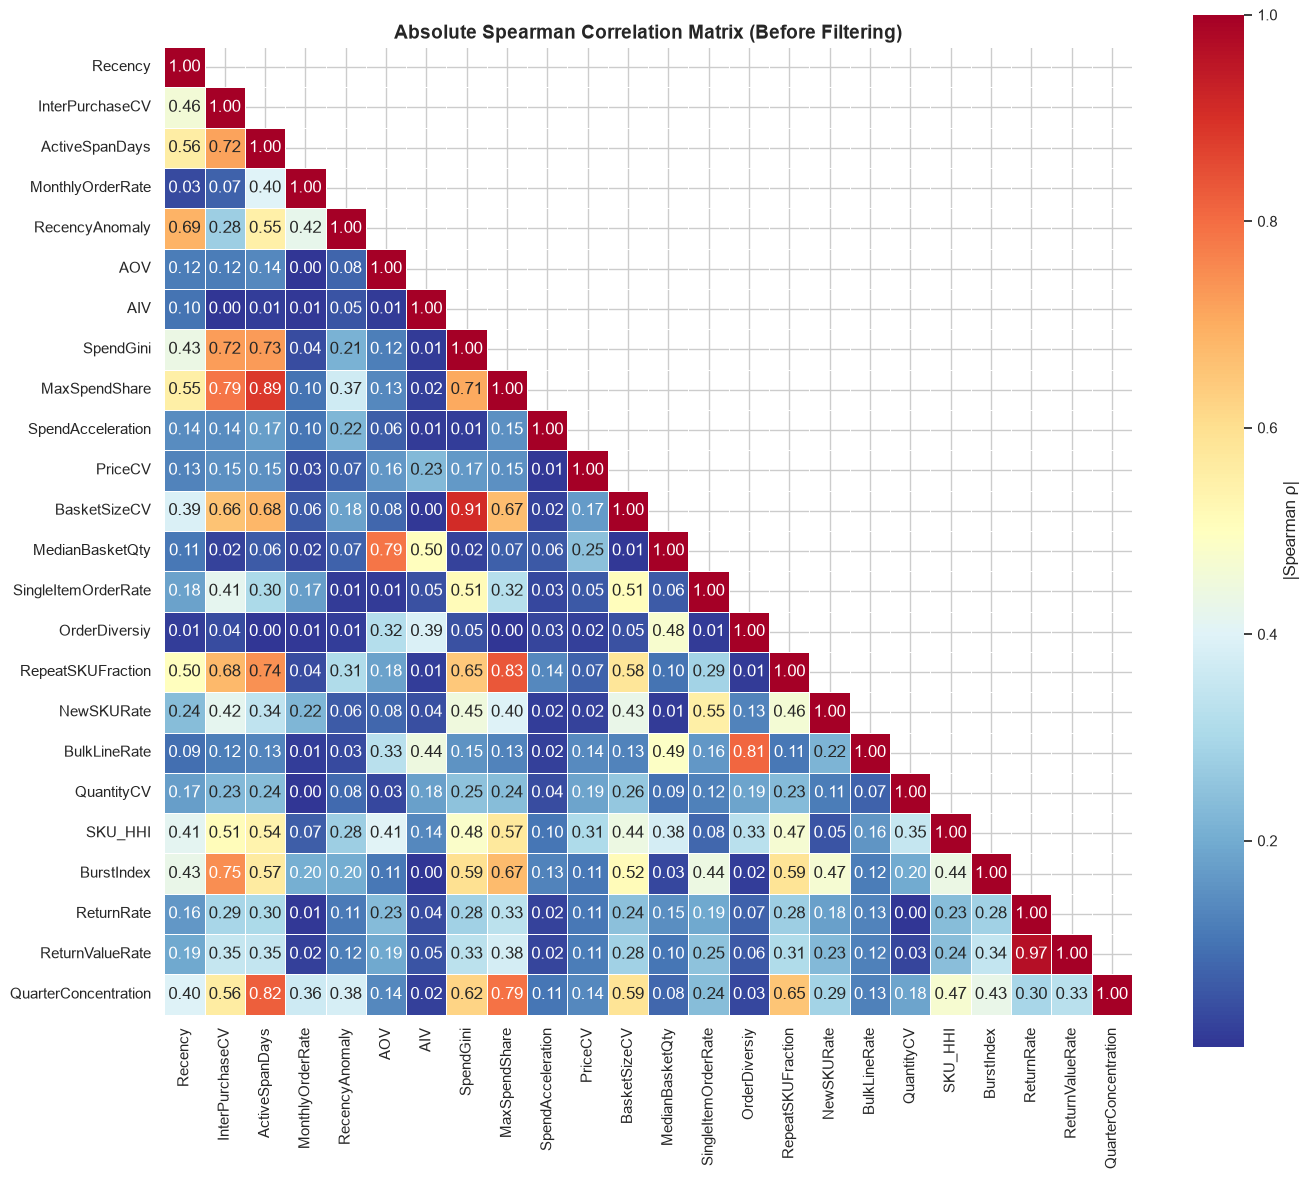

  Dropped 'ReturnValueRate' (|corr(ReturnRate, ReturnValueRate)| = 0.968)
  Dropped 'SpendGini' (|corr(SpendGini, BasketSizeCV)| = 0.907)
  Dropped 'ActiveSpanDays' (|corr(ActiveSpanDays, MaxSpendShare)| = 0.885)

CORRELATION FILTER RESULTS
Features before: 24
Features after:  21
Dropped (3): ['ReturnValueRate', 'SpendGini', 'ActiveSpanDays']

Retained features:
   1. Recency (protected)
   2. InterPurchaseCV
   3. MonthlyOrderRate (protected)
   4. RecencyAnomaly
   5. AOV
   6. AIV
   7. MaxSpendShare
   8. SpendAcceleration
   9. PriceCV
  10. BasketSizeCV
  11. MedianBasketQty
  12. SingleItemOrderRate
  13. OrderDiversiy
  14. RepeatSKUFraction
  15. NewSKURate
  16. BulkLineRate
  17. QuantityCV
  18. SKU_HHI (protected)
  19. BurstIndex
  20. ReturnRate (protected)
  21. QuarterConcentration (protected)


In [16]:
# Threshold: |Spearman correlation| > 0.85 → drop the non-protected feature
# with the highest mean absolute correlation

CORR_THRESHOLD = 0.85
PROTECTED_FEATURES = ['Recency', 'MonthlyOrderRate', 'ReturnRate',
                       'QuarterConcentration', 'SKU_HHI']

# Compute Spearman correlation
corr_matrix = df_retail.corr(method='spearman').abs()

# Visualize before filtering
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0.5, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'label': '|Spearman ρ|'})
ax.set_title('Absolute Spearman Correlation Matrix (Before Filtering)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Greedy filter
features_to_keep = list(df_retail.columns)
dropped_features = []

while True:
    # Recompute correlation for remaining features
    corr_sub = df_retail[features_to_keep].corr(method='spearman').abs()
    # Zero the diagonal using pandas (pandas 3.x .values is read-only)
    for col in corr_sub.columns:
        corr_sub.loc[col, col] = 0.0

    # Find max correlation pair
    max_corr = corr_sub.max().max()
    if max_corr <= CORR_THRESHOLD:
        break

    # Find the pair
    pair = corr_sub.stack().idxmax()
    feat_a, feat_b = pair

    # Decide which to drop: prefer non-protected, then highest mean |corr|
    a_protected = feat_a in PROTECTED_FEATURES
    b_protected = feat_b in PROTECTED_FEATURES

    if a_protected and b_protected:
        # Both protected — drop the one with higher mean correlation to others
        mean_a = corr_sub[feat_a].mean()
        mean_b = corr_sub[feat_b].mean()
        to_drop = feat_a if mean_a > mean_b else feat_b
    elif a_protected:
        to_drop = feat_b
    elif b_protected:
        to_drop = feat_a
    else:
        # Neither protected — drop the one with higher mean correlation
        mean_a = corr_sub[feat_a].mean()
        mean_b = corr_sub[feat_b].mean()
        to_drop = feat_a if mean_a > mean_b else feat_b

    features_to_keep.remove(to_drop)
    dropped_features.append((to_drop, feat_a, feat_b, max_corr))
    print(f"  Dropped '{to_drop}' (|corr({feat_a}, {feat_b})| = {max_corr:.3f})")

print(f"\n{'=' * 60}")
print(f"CORRELATION FILTER RESULTS")
print(f"{'=' * 60}")
print(f"Features before: {len(df_retail.columns)}")
print(f"Features after:  {len(features_to_keep)}")
print(f"Dropped ({len(dropped_features)}): {[d[0] for d in dropped_features]}")
print(f"\nRetained features:")
for i, f in enumerate(features_to_keep, 1):
    protected = ' (protected)' if f in PROTECTED_FEATURES else ''
    print(f"  {i:2d}. {f}{protected}")

# Apply filter
df_filtered = df_retail[features_to_keep].copy()

### Step 7: Advanced Data Transformation Pipeline

**Objective:** E-commerce data is heavily right-skewed with extreme outliers (e.g., massive B2B orders). Standard scaling alone is insufficient and would distort the clustering space.

**Approach:** 
We implement a robust 3-step transformation pipeline:
1. **`QuantileTransformer`:** Forces all features into a strict Normal Distribution (Gaussian), completely mitigating skewness and neutralizing extreme outliers.
2. **`StandardScaler`:** Polishes the output to ensure exact $\mu = 0$ and $\sigma = 1$ across all features.
3. **`Clipping`:** Restricts all values to $[-3.0, 3.0]$ (the 3-sigma rule) to guarantee strict boundaries for the K-Means distance calculations.

TRANSFORMATION VERIFICATION


,mean,std,min,max
Recency,0.0249,0.8905,-3.0000,3.0000
InterPurchaseCV,0.0000,1.0001,-0.9303,2.4840
MonthlyOrderRate,0.0003,0.9933,-3.0000,3.0000
RecencyAnomaly,-0.0003,0.9921,-3.0000,3.0000
AOV,0.0002,0.9948,-3.0000,3.0000
AIV,-0.0001,0.9949,-3.0000,3.0000
MaxSpendShare,-0.0000,1.0001,-2.3736,1.3789
SpendAcceleration,0.0015,0.9889,-3.0000,3.0000
PriceCV,0.0100,0.9555,-3.0000,3.0000
BasketSizeCV,0.0000,1.0001,-1.3435,2.3698



✅ All values in [-3.0, 3.0]


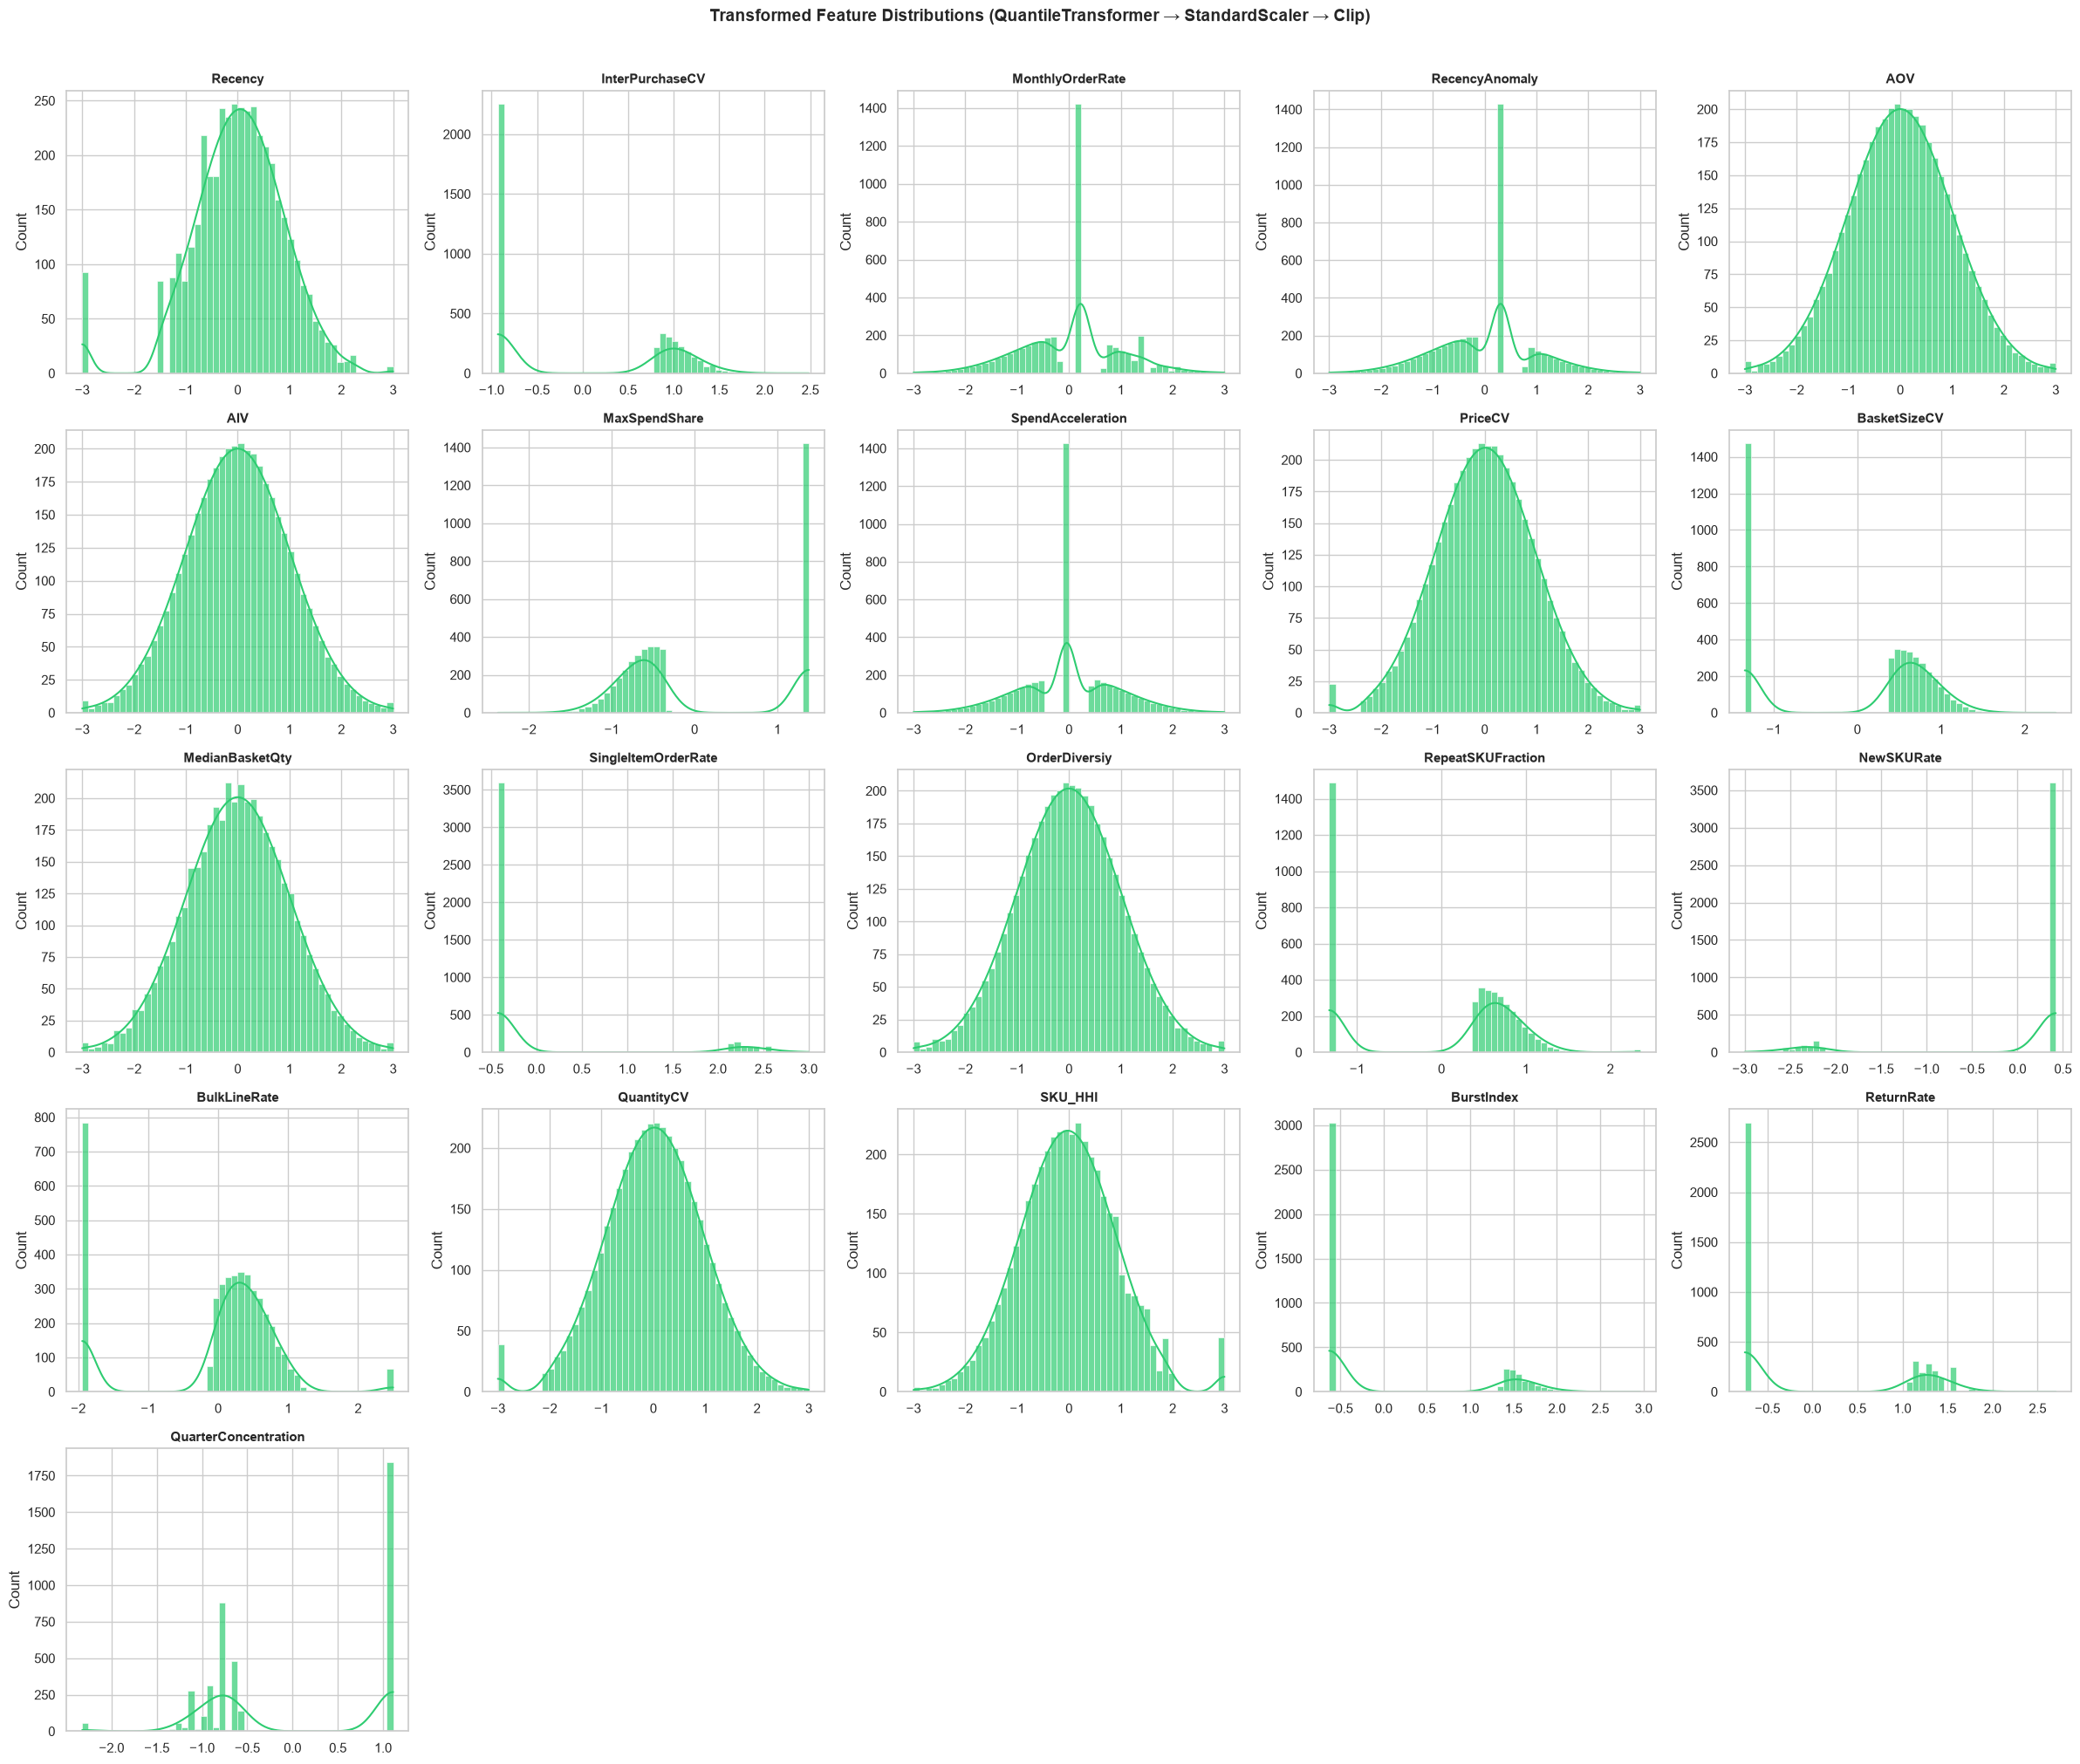

In [17]:
feature_cols = df_filtered.columns.tolist()

# Step 1: QuantileTransformer
qt = QuantileTransformer(output_distribution='normal', random_state=42)
df_qt = pd.DataFrame(
    qt.fit_transform(df_filtered),
    columns=feature_cols,
    index=df_filtered.index
)

# Step 2: StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_qt),
    columns=feature_cols,
    index=df_filtered.index
)

# Step 3: Clip to [-3, 3]
df_transformed = df_scaled.clip(lower=-3.0, upper=3.0)

# Verify transformation results
print("=" * 70)
print("TRANSFORMATION VERIFICATION")
print("=" * 70)
stats = pd.DataFrame({
    'mean': df_transformed.mean(),
    'std': df_transformed.std(),
    'min': df_transformed.min(),
    'max': df_transformed.max(),
}).round(4)
display(stats)

# Verify all values in [-3, 3]
assert df_transformed.min().min() >= -3.0, "Values below -3.0!"
assert df_transformed.max().max() <= 3.0, "Values above 3.0!"
print("\n✅ All values in [-3.0, 3.0]")

# Histogram grid of transformed features
n_features = len(feature_cols)
n_cols_plot = 5
n_rows_plot = (n_features + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(24, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    sns.histplot(df_transformed[col], kde=True, ax=ax, bins=50,
                 color='#2ecc71', edgecolor='white', alpha=0.7)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Transformed Feature Distributions (QuantileTransformer → StandardScaler → Clip)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Step 8: Dimensionality Balancing (Feature Family Weighting)

**Objective:** Prevent "Feature Bloat." Our behavioral dimensions (Families) have an unequal number of features (e.g., Spend has 6, Lifecycle has 2). If left unweighted, the Euclidean distance would be dominated by the Spend dimension.

**Approach:** 
We apply a weight of $w = \frac{1}{\sqrt{n}}$ to each feature, where $n$ is the number of retained features in its family. Since Euclidean distance operates on squared differences, this mathematically guarantees that every behavioral family exerts an exact equal weight ($1.0$) in the final K-Means space.

In [18]:
# Cell 9: Family Weighting
# Weight = 1 / sqrt(n_features_in_family)
# Ensures each of the 5 behavioral dimensions contributes equally in Euclidean distance

FEATURE_FAMILIES = {
    'Purchase Rhythm': ['Recency', 'InterPurchaseCV', 'ActiveSpanDays', 'MonthlyOrderRate','RecencyAnomaly'],
    'Spend Shape': ['AOV', 'AIV','SpendGini', 'PriceCV', 'MaxSpendShare', 'SpendAcceleration'],
    'Basket Behavior': ['RepeatSKUFraction', 'BasketSizeCV', 'MedianBasketQty', 'NewSKURate','SingleItemOrderRate','OrderDiversity'],
    'Volume & B2B': ['BulkLineRate', 'QuantityCV', 'SKU_HHI', 'BurstIndex'],
    'Customer Lifecycle': ['ReturnRate', 'ReturnValueRate', 'QuarterConcentration'],
}

# Build weight lookup for retained features only
retained_features = df_transformed.columns.tolist()
weight_dict = {}

print(f"{'Family':<25s} {'Retained Features':<55s} {'n':>3s}  {'Weight':>8s}")
print("=" * 95)

for family, members in FEATURE_FAMILIES.items():
    # Only count retained members
    retained_members = [f for f in members if f in retained_features]
    n = len(retained_members)
    if n > 0:
        w = 1.0 / np.sqrt(n)
        for f in retained_members:
            weight_dict[f] = w
        print(f"{family:<25s} {str(retained_members):<55s} {n:3d}  {w:8.4f}")

print(f"\nTotal weighted features: {len(weight_dict)}")

# Apply weights
df_weighted = df_transformed.copy()
for col in df_weighted.columns:
    df_weighted[col] *= weight_dict.get(col, 1.0)

# Verify: show weighted feature variances (should be ~equal within families)
print(f"\n{'Feature':<25s} {'Weight':>8s} {'Weighted Var':>14s}")
print("-" * 50)
for col in df_weighted.columns:
    w = weight_dict.get(col, 1.0)
    var = df_weighted[col].var()
    print(f"{col:<25s} {w:8.4f} {var:14.4f}")

Family                    Retained Features                                         n    Weight
Purchase Rhythm           ['Recency', 'InterPurchaseCV', 'MonthlyOrderRate', 'RecencyAnomaly']   4    0.5000
Spend Shape               ['AOV', 'AIV', 'PriceCV', 'MaxSpendShare', 'SpendAcceleration']   5    0.4472
Basket Behavior           ['RepeatSKUFraction', 'BasketSizeCV', 'MedianBasketQty', 'NewSKURate', 'SingleItemOrderRate']   5    0.4472
Volume & B2B              ['BulkLineRate', 'QuantityCV', 'SKU_HHI', 'BurstIndex']   4    0.5000
Customer Lifecycle        ['ReturnRate', 'QuarterConcentration']                    2    0.7071

Total weighted features: 20

Feature                     Weight   Weighted Var
--------------------------------------------------
Recency                     0.5000         0.1982
InterPurchaseCV             0.5000         0.2501
MonthlyOrderRate            0.5000         0.2467
RecencyAnomaly              0.5000         0.2460
AOV                         0.4472

In [19]:
# Cell 10: Save Output
# Save the retail cohort (scaled + weighted, ~14 features + CustomerID)

output_path = '../data/processed/retail_features_clean.csv'
df_weighted.to_csv(output_path)

# Final sanity checks
print("=" * 70)
print("FINAL OUTPUT SUMMARY")
print("=" * 70)
print(f"Output path: {output_path}")
print(f"Shape: {df_weighted.shape}")
print(f"NaN count: {df_weighted.isna().sum().sum()}")
print(f"Inf count: {np.isinf(df_weighted.values).sum()}")
print(f"\nDescriptive statistics:")
display(df_weighted.describe().T.round(4))

print(f"\n Retail features saved to {output_path}")

FINAL OUTPUT SUMMARY
Output path: ../data/processed/retail_features_clean.csv
Shape: (4238, 21)
NaN count: 0
Inf count: 0

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Recency,4238.0,0.0124,0.4452,-1.5000,-0.2452,0.0247,0.3006,1.5000
InterPurchaseCV,4238.0,0.0000,0.5001,-0.4651,-0.4651,-0.4651,0.4991,1.2420
MonthlyOrderRate,4238.0,0.0002,0.4967,-1.5000,-0.3377,0.1131,0.1131,1.5000
RecencyAnomaly,4238.0,-0.0001,0.4960,-1.5000,-0.3374,0.1549,0.1549,1.5000
AOV,4238.0,0.0001,0.4449,-1.3416,-0.3003,-0.0003,0.3009,1.3416
AIV,4238.0,-0.0000,0.4449,-1.3416,-0.3006,0.0003,0.3006,1.3416
MaxSpendShare,4238.0,-0.0000,0.4473,-1.0615,-0.3312,-0.2224,0.6167,0.6167
SpendAcceleration,4238.0,0.0007,0.4422,-1.3416,-0.3022,-0.0188,0.3022,1.3416
PriceCV,4238.0,0.0045,0.4273,-1.3416,-0.2815,0.0049,0.2921,1.3416
BasketSizeCV,4238.0,0.0000,0.4473,-0.6008,-0.6008,0.2294,0.3372,1.0598



 Retail features saved to ../data/processed/retail_features_clean.csv
